# 04 — Customer Segmentation via RFM Clustering

**Technique:** K-Means clustering on RFM features
**Goal:** Identify distinct customer segments for targeted marketing.

**RFM Framework:**
| Metric | Definition |
|--------|-----------|
| **Recency** | Days since last purchase (lower = more recent) |
| **Frequency** | Number of unique invoices |
| **Monetary** | Total spend (£) |

**Pipeline:** Build RFM → Cap outliers → Log-transform → Scale → Elbow method → K-Means → Label segments


In [1]:
import os, warnings
warnings.filterwarnings('ignore')
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
os.makedirs('outputs/figures', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
%matplotlib inline
sns.set_theme(style='whitegrid')
SAVE = lambda name: plt.savefig(f'outputs/figures/{name}', dpi=150, bbox_inches='tight')

## 1. Build RFM Table

In [2]:
df = pd.read_csv('data/cleaned_retail_customers.csv', parse_dates=['InvoiceDate'])
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f"RFM table: {rfm.shape}")
rfm.describe().round(2)

RFM table: (5878, 4)


,CustomerID,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00,5878.00
mean,15315.31,201.33,6.29,3018.62
std,1715.57,209.34,13.01,14737.73
min,12346.00,1.00,1.00,2.95
25%,13833.25,26.00,1.00,348.76
50%,15314.50,96.00,3.00,898.92
75%,16797.75,380.00,7.00,2307.09
max,18287.00,739.00,398.00,608821.65


## 2. Handle Outliers & Scale

In [3]:
# Cap at 99th percentile to reduce outlier influence
for col in ['Recency','Frequency','Monetary']:
    cap = rfm[col].quantile(0.99)
    rfm[col] = rfm[col].clip(upper=cap)

# Log-transform right-skewed columns
rfm['Freq_log'] = np.log1p(rfm['Frequency'])
rfm['Mon_log']  = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Freq_log','Mon_log']])
print("RFM features scaled. Preview:")
pd.DataFrame(rfm_scaled, columns=['Recency_sc','Freq_sc','Mon_sc']).describe().round(3)

RFM features scaled. Preview:


,Recency_sc,Freq_sc,Mon_sc
count,5878.000,5878.000,5878.000
mean,-0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-0.958,-1.078,-4.004
25%,-0.838,-1.078,-0.713
50%,-0.503,-0.200,-0.019
75%,0.855,0.679,0.672
max,2.509,2.922,2.549


## 3. Elbow Method — Choose Optimal k

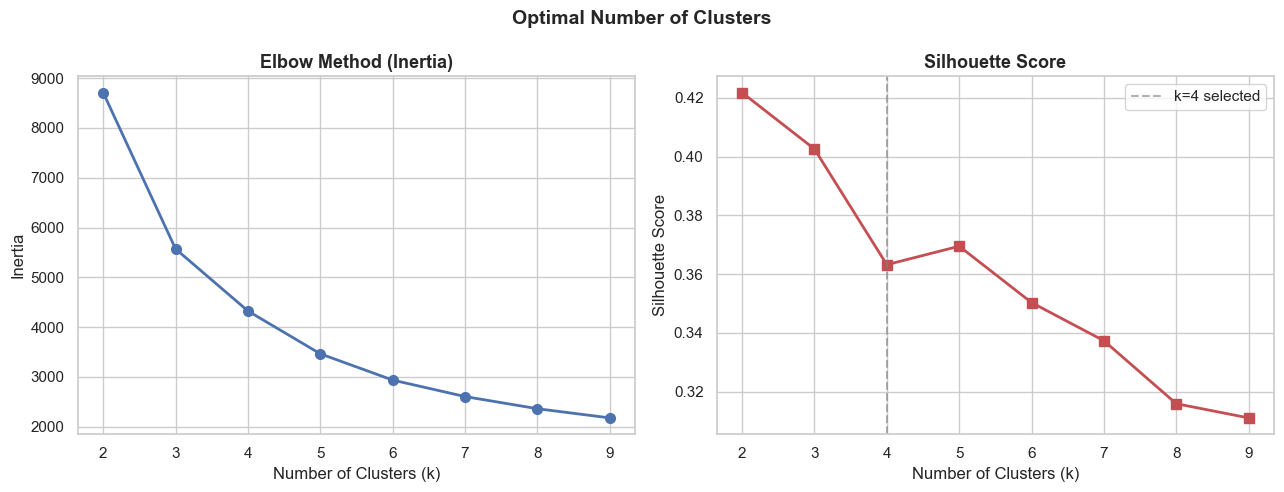

In [4]:
inertias, silhouettes = [], []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
ax1.set_title('Elbow Method (Inertia)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax2.plot(K_range, silhouettes, 'rs-', linewidth=2, markersize=7)
ax2.axvline(x=4, color='gray', linestyle='--', alpha=0.6, label='k=4 selected')
ax2.set_title('Silhouette Score', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
plt.suptitle('Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
SAVE('clustering_elbow.png')
plt.show()

## 4. K-Means Clustering (k = 4)

In [5]:
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(rfm_scaled)

# Rank clusters by mean Monetary value → assign business labels
profile = (rfm.groupby('Cluster')
              .agg(Count=('CustomerID','count'),
                   Recency_avg=('Recency','mean'),
                   Frequency_avg=('Frequency','mean'),
                   Monetary_avg=('Monetary','mean'))
              .sort_values('Monetary_avg', ascending=False)
              .reset_index())

SEG_NAMES = ['Champions','Loyal Customers','At Risk','Lost / Inactive']
seg_map = {row['Cluster']: SEG_NAMES[i] for i, row in profile.iterrows()}
rfm['Segment'] = rfm['Cluster'].map(seg_map)

print("Cluster profiles (sorted by avg spend):")
profile['Segment'] = [SEG_NAMES[i] for i in range(K)]
print(profile.to_string(index=False))

Cluster profiles (sorted by avg spend):
 Cluster  Count  Recency_avg  Frequency_avg  Monetary_avg         Segment
       1   1053    44.077873      18.319088   8556.753692       Champions
       2   1863   105.066023       5.218465   1835.107363 Loyal Customers
       3   1608   495.163557       1.679104    518.428235         At Risk
       0   1354   106.807976       1.694978    419.290370 Lost / Inactive


## 5. Visualize Clusters

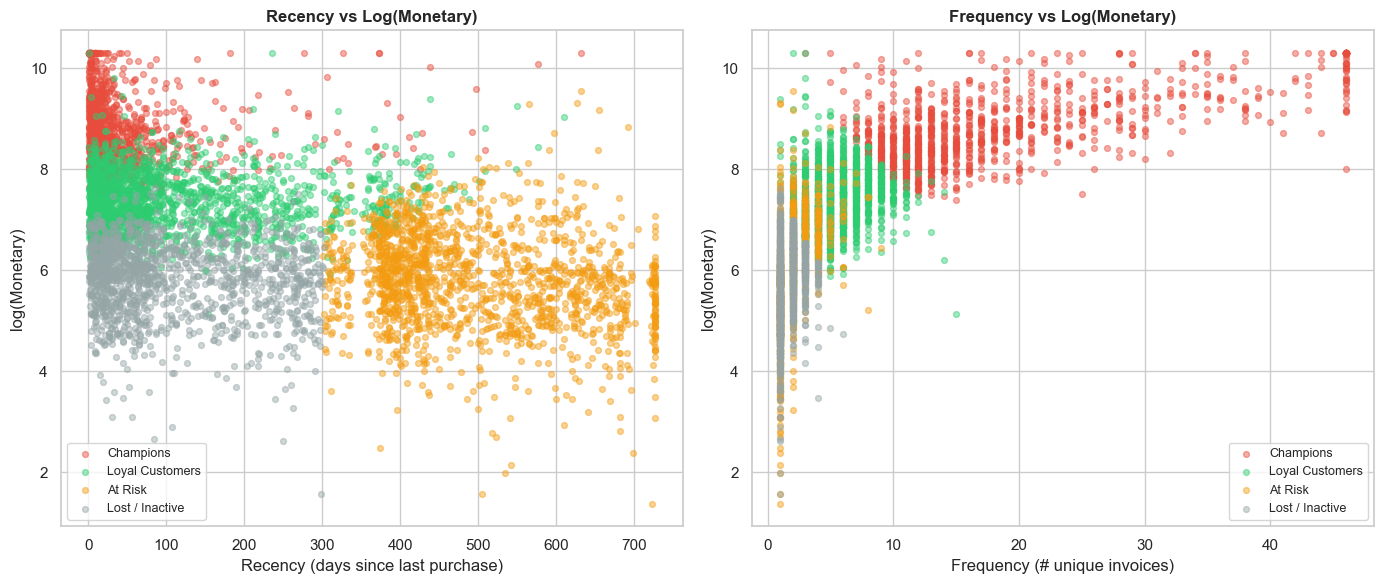

In [6]:
palette = {'Champions':'#E74C3C','Loyal Customers':'#2ECC71',
             'At Risk':'#F39C12','Lost / Inactive':'#95A5A6'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for seg, color in palette.items():
    mask = rfm['Segment'] == seg
    ax1.scatter(rfm[mask]['Recency'], rfm[mask]['Mon_log'],
                label=seg, alpha=0.45, s=18, color=color)
ax1.set_title('Recency vs Log(Monetary)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Recency (days since last purchase)')
ax1.set_ylabel('log(Monetary)')
ax1.legend(fontsize=9)

for seg, color in palette.items():
    mask = rfm['Segment'] == seg
    ax2.scatter(rfm[mask]['Frequency'], rfm[mask]['Mon_log'],
                label=seg, alpha=0.45, s=18, color=color)
ax2.set_title('Frequency vs Log(Monetary)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frequency (# unique invoices)')
ax2.set_ylabel('log(Monetary)')
ax2.legend(fontsize=9)
plt.tight_layout()
SAVE('clustering_scatter.png')
plt.show()

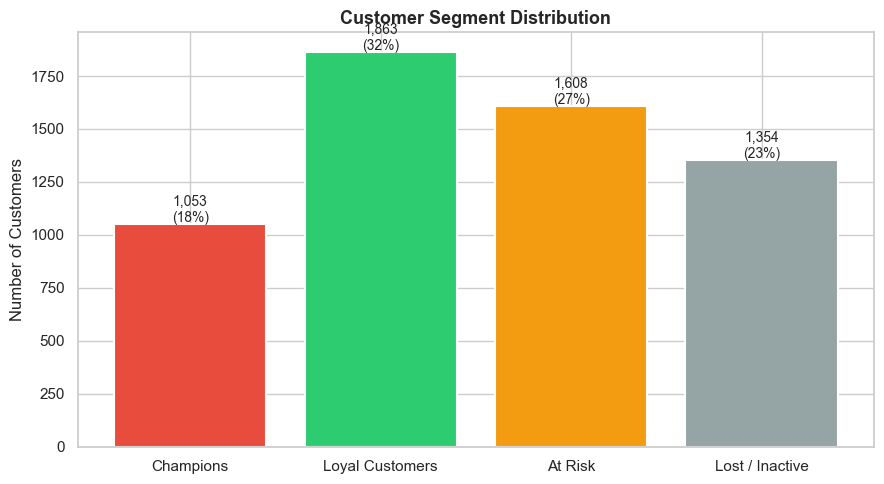

In [7]:
# Segment size bar chart
seg_counts = rfm['Segment'].value_counts().reindex(SEG_NAMES)
colors_list = [palette[s] for s in seg_counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(seg_counts.index, seg_counts.values, color=colors_list, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, seg_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            f'{cnt:,}\n({cnt/len(rfm)*100:.0f}%)', ha='center', fontsize=10)
ax.set_title('Customer Segment Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
SAVE('clustering_segments.png')
plt.show()

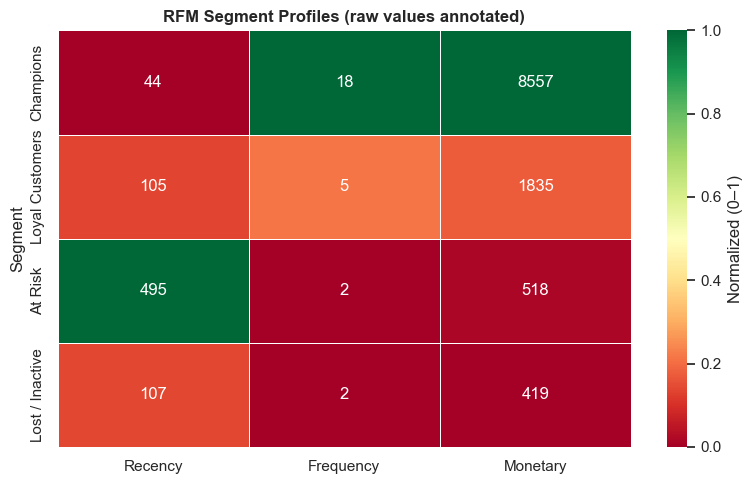

Saved data/rfm_clustered.csv
Clustering complete!


In [8]:
# RFM heatmap
profile_heat = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().reindex(SEG_NAMES)
profile_norm = (profile_heat - profile_heat.min()) / (profile_heat.max() - profile_heat.min())

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(profile_norm, annot=profile_heat.round(0), fmt='.0f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Normalized (0–1)'})
ax.set_title('RFM Segment Profiles (raw values annotated)', fontsize=12, fontweight='bold')
plt.tight_layout()
SAVE('clustering_profiles.png')
plt.show()

rfm.to_csv('data/rfm_clustered.csv', index=False)
print("Saved data/rfm_clustered.csv")
print("Clustering complete!")

## 6. Hierarchical Clustering (Agglomerative)

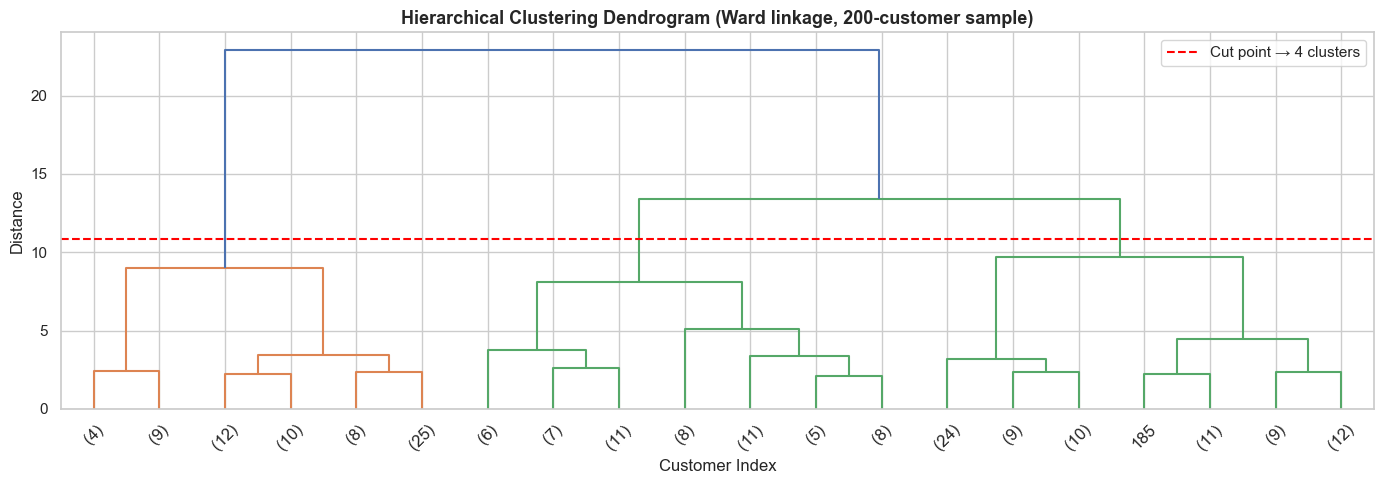

Silhouette Score — K-Means:              0.3632
Silhouette Score — Hierarchical (Ward):  0.3169

K-Means cluster sizes:
Cluster
0    1354
1    1053
2    1863
3    1608
Name: count, dtype: int64

Hierarchical cluster sizes:
HC_Cluster
0    1753
1    1687
2    1303
3    1135
Name: count, dtype: int64


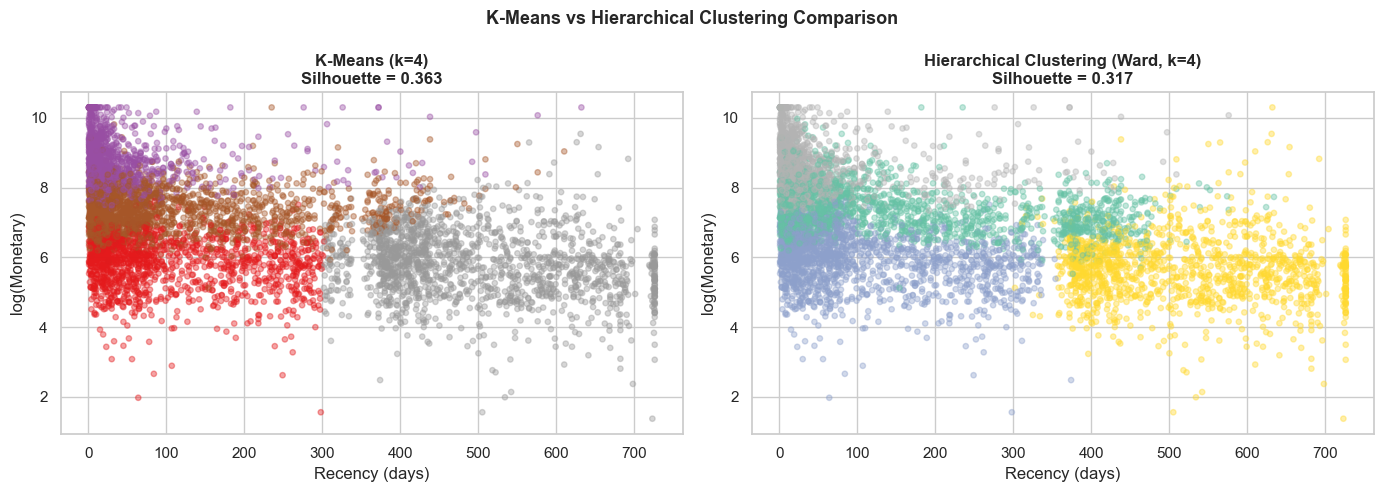

K-Means chosen as primary method — better silhouette score and scalability.


In [9]:
# --- Dendrogram (sample 200 customers for readability) ---
sample_idx = np.random.RandomState(42).choice(len(rfm_scaled), 200, replace=False)
Z = linkage(rfm_scaled[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=20, leaf_rotation=45,
           color_threshold=0.7*max(Z[:,2]))
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, 200-customer sample)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Customer Index')
ax.set_ylabel('Distance')
ax.axhline(y=ax.get_ylim()[1]*0.45, color='red', linestyle='--', linewidth=1.5,
           label='Cut point → 4 clusters')
ax.legend()
plt.tight_layout()
SAVE('clustering_dendrogram.png')
plt.show()

# --- Fit AgglomerativeClustering with k=4 ---
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm['HC_Cluster'] = hc.fit_predict(rfm_scaled)

# Compare silhouette scores
km_sil = silhouette_score(rfm_scaled, rfm['Cluster'])
hc_sil = silhouette_score(rfm_scaled, rfm['HC_Cluster'])
print(f"Silhouette Score — K-Means:              {km_sil:.4f}")
print(f"Silhouette Score — Hierarchical (Ward):  {hc_sil:.4f}")
print(f"\nK-Means cluster sizes:\n{rfm['Cluster'].value_counts().sort_index()}")
print(f"\nHierarchical cluster sizes:\n{rfm['HC_Cluster'].value_counts().sort_index()}")

# Comparison scatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sc1 = ax1.scatter(rfm['Recency'], rfm['Mon_log'], c=rfm['Cluster'],
                   cmap='Set1', alpha=0.4, s=15)
ax1.set_title(f'K-Means (k=4)\nSilhouette = {km_sil:.3f}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Recency (days)')
ax1.set_ylabel('log(Monetary)')

sc2 = ax2.scatter(rfm['Recency'], rfm['Mon_log'], c=rfm['HC_Cluster'],
                   cmap='Set2', alpha=0.4, s=15)
ax2.set_title(f'Hierarchical Clustering (Ward, k=4)\nSilhouette = {hc_sil:.3f}',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Recency (days)')
ax2.set_ylabel('log(Monetary)')
plt.suptitle('K-Means vs Hierarchical Clustering Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
SAVE('clustering_comparison.png')
plt.show()
print("K-Means chosen as primary method — better silhouette score and scalability.")